# Field Development Process and Reservoir Coupling

This notebook demonstrates route-aware tieback screening, multi-well network allocation, process-model generation from a `FieldConcept`, and reservoir-coupling exports. It uses workspace Java classes through `devtools/neqsim_dev_setup.py`.

In [1]:
import importlib.util
import os
import sys
from pathlib import Path


def find_neqsim_project_root():
    env_root = os.environ.get("NEQSIM_PROJECT_ROOT")
    candidates = []
    if env_root:
        candidates.append(Path(env_root).resolve())
    cwd = Path.cwd().resolve()
    candidates.extend([cwd] + list(cwd.parents))
    for candidate in candidates:
        if (candidate / "pom.xml").exists() and (candidate / "devtools" / "neqsim_dev_setup.py").exists():
            return candidate
    raise RuntimeError("Could not find NeqSim project root. Set NEQSIM_PROJECT_ROOT.")


PROJECT_ROOT = find_neqsim_project_root()
DEVTOOLS_DIR = PROJECT_ROOT / "devtools"
sys.path.insert(0, str(DEVTOOLS_DIR))

setup_path = DEVTOOLS_DIR / "neqsim_dev_setup.py"
setup_spec = importlib.util.spec_from_file_location("neqsim_dev_setup", setup_path)
if setup_spec is None or setup_spec.loader is None:
    raise RuntimeError(f"Could not load devtools setup module from {setup_path}")
setup_module = importlib.util.module_from_spec(setup_spec)
setup_spec.loader.exec_module(setup_module)

neqsim_init = setup_module.neqsim_init
neqsim_classes = setup_module.neqsim_classes

ns = neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=True)
ns = neqsim_classes(ns)
NEQSIM_MODE = "devtools"
NOTEBOOK_DIR = (PROJECT_ROOT / "examples" / "notebooks").resolve()
FIGURES_DIR = NOTEBOOK_DIR / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
print("NeqSim loaded via devtools workspace classes")

NeqSim project root: C:\Users\ESOL\Documents\GitHub\neqsim
Classpath:
  1. C:\Users\ESOL\Documents\GitHub\neqsim\target\classes
  2. C:\Users\ESOL\Documents\GitHub\neqsim\src\main\resources
  3. C:\Users\ESOL\.m2\repository\com\h2database\h2\2.4.240\h2-2.4.240.jar
  4. C:\Users\ESOL\.m2\repository\org\apache\logging\log4j\log4j-api\2.25.4\log4j-api-2.25.4.jar
  5. C:\Users\ESOL\.m2\repository\org\apache\logging\log4j\log4j-core\2.25.4\log4j-core-2.25.4.jar
  6. C:\Users\ESOL\.m2\repository\com\thoughtworks\xstream\xstream\1.4.21\xstream-1.4.21.jar
  7. C:\Users\ESOL\.m2\repository\io\github\x-stream\mxparser\1.2.2\mxparser-1.2.2.jar
  8. C:\Users\ESOL\.m2\repository\xmlpull\xmlpull\1.1.3.1\xmlpull-1.1.3.1.jar
  9. C:\Users\ESOL\.m2\repository\org\apache\commons\commons-lang3\3.20.0\commons-lang3-3.20.0.jar
  10. C:\Users\ESOL\.m2\repository\org\apache\commons\commons-math3\3.6.1\commons-math3-3.6.1.jar
  11. C:\Users\ESOL\.m2\repository\org\ejml\ejml-all\0.44.0\ejml-all-0.44.0.jar
  12


JVM started: C:\Users\ESOL\graalvm\graalvm-jdk-25.0.1+8.1\bin\server\jvm.dll
Ready — call neqsim_classes(ns) to import classes


All NeqSim classes imported OK
NeqSim loaded via devtools workspace classes


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

FieldConcept = ns.JClass("neqsim.process.fielddevelopment.concept.FieldConcept")
ReservoirInput = ns.JClass("neqsim.process.fielddevelopment.concept.ReservoirInput")
WellsInput = ns.JClass("neqsim.process.fielddevelopment.concept.WellsInput")
InfrastructureInput = ns.JClass("neqsim.process.fielddevelopment.concept.InfrastructureInput")
TiebackRouteNetwork = ns.JClass("neqsim.process.fielddevelopment.network.TiebackRouteNetwork")
TiebackAnalyzer = ns.JClass("neqsim.process.fielddevelopment.tieback.TiebackAnalyzer")
HostFacility = ns.JClass("neqsim.process.fielddevelopment.tieback.HostFacility")
NetworkSolver = ns.JClass("neqsim.process.fielddevelopment.network.NetworkSolver")
ConceptToProcessLinker = ns.JClass("neqsim.process.fielddevelopment.facility.ConceptToProcessLinker")
ReservoirCouplingExporter = ns.JClass("neqsim.process.fielddevelopment.reservoir.ReservoirCouplingExporter")
WellSystem = ns.JClass("neqsim.process.equipment.reservoir.WellSystem")
Stream = ns.JClass("neqsim.process.equipment.stream.Stream")
GregorianCalendar = ns.JClass("java.util.GregorianCalendar")
Calendar = ns.JClass("java.util.Calendar")

plt.rcParams.update({"figure.figsize": (9, 4.8), "axes.grid": True})


def create_gas_fluid():
    fluid = ns.SystemSrkEos(273.15 + 85.0, 250.0)
    fluid.addComponent("methane", 0.85)
    fluid.addComponent("ethane", 0.08)
    fluid.addComponent("propane", 0.04)
    fluid.addComponent("n-butane", 0.02)
    fluid.addComponent("CO2", 0.01)
    fluid.setMixingRule("classic")
    fluid.init(0)
    return fluid


def create_gas_well(name, productivity_index, base_rate_msm3d):
    reservoir_stream = Stream(name + " reservoir", create_gas_fluid())
    reservoir_stream.setFlowRate(base_rate_msm3d, "MSm3/day")
    reservoir_stream.setTemperature(85.0, "C")
    reservoir_stream.setPressure(250.0, "bara")
    reservoir_stream.run()

    well = WellSystem(name)
    well.setReservoirStream(reservoir_stream)
    well.setProductionIndex(productivity_index, "Sm3/day/bar2")
    well.setIPRModel(WellSystem.IPRModel.PRODUCTION_INDEX)
    well.setWellheadPressure(50.0, "bara")
    well.setTubingDiameter(0.12, "m")
    well.setTubingLength(2500.0, "m")
    return well

## 1. Route-Aware Tieback Screening

A `TiebackRouteNetwork` stores main flowlines, shared corridors, branches, risers, and host hubs. The tieback analyzer uses the equivalent route for hydraulic screening while preserving installed length and topology for reporting.

In [3]:
concept = FieldConcept.builder("Lean Gas Satellite").reservoir(
    ReservoirInput.leanGas().gor(12000.0).resourceEstimate(8.0, "GSm3").build()
).wells(
    WellsInput.builder().producerCount(2).ratePerWell(0.8e6, "Sm3/d").tubeheadPressure(90.0).build()
).infrastructure(
    InfrastructureInput.subseaTieback().tiebackLength(30.0).waterDepth(250.0).exportPressure(150.0).build()
).build()

host = HostFacility.builder("Platform A").location(61.5, 2.3).waterDepth(120).spareGasCapacity(5.0).spareOilCapacity(20000.0).minTieInPressure(80.0).build()
route = TiebackRouteNetwork.builder("Shared corridor to Platform A").hostHub("Platform A hub").addSharedCorridor("Common corridor", 20.0, 12.0, 300.0).addFlowline("Discovery flowline", 10.0, 10.0, 350.0).addBranch("Future branch", 5.0, 8.0, 350.0).addRiser("Steel catenary riser", 1.0, 10.0, 300.0).build()

option = TiebackAnalyzer().evaluateSingleTieback(concept, host, route, 61.6, 2.4)

route_rows = []
for segment in route.getSegments():
    route_rows.append({
        "segment": str(segment.getName()),
        "type": str(segment.getType().name()),
        "length_km": segment.getLengthKm(),
        "diameter_in": segment.getDiameterInches(),
        "inlet_depth_m": segment.getInletWaterDepthM(),
        "outlet_depth_m": segment.getOutletWaterDepthM(),
        "shared": bool(segment.isShared()),
    })
route_df = pd.DataFrame(route_rows)
tieback_df = pd.DataFrame([{
    "host": str(option.getHostName()),
    "screening_length_km": option.getDistanceKm(),
    "installed_length_km": option.getRouteInstalledLengthKm(),
    "shared_corridor_km": option.getRouteSharedCorridorLengthKm(),
    "arrival_pressure_bara": option.getArrivalPressureBara(),
    "arrival_temperature_C": option.getArrivalTemperatureC(),
    "hydrate_margin_C": option.getHydrateMarginC(),
    "capex_MUSD": option.getTotalCapexMusd(),
    "npv_MUSD": option.getNpvMusd(),
    "feasible": bool(option.isFeasible()),
}])
display(route_df.round(2))
display(tieback_df.round(2))
print(route.getSummary())
print(option.getFlowAssuranceNotes())

,segment,type,length_km,diameter_in,inlet_depth_m,outlet_depth_m,shared
0,Common corridor,SHARED_CORRIDOR,20.0,12.0,300.0,300.0,True
1,Discovery flowline,FLOWLINE,10.0,10.0,350.0,350.0,False
2,Future branch,BRANCH,5.0,8.0,350.0,350.0,False
3,Steel catenary riser,RISER,1.0,10.0,300.0,0.0,False


,host,screening_length_km,installed_length_km,shared_corridor_km,arrival_pressure_bara,arrival_temperature_C,hydrate_margin_C,capex_MUSD,npv_MUSD,feasible
0,Platform A,31.0,36.0,20.0,81.83,6.46,-6.72,411.8,58.18,True


Shared corridor to Platform A: 31.0 km main / 36.0 km installed, 1 branches, 1 risers, 20.0 km shared, hub Platform A hub
Hydraulics: route 31.0 km, seabed 4.0 C, U 5.1 W/m2K. Arrival 81.8 bara / 6.5 C, regime ANNULAR, erosional ratio 0.23. Hydrate formation 13.2 C, margin -6.7 C. Shutdown cooldown risk 55%, time to hydrate 16.9 h. Hydrate calculation estimated - detailed analysis required Arrival temperature 6.5°C too close to seabed 4.0°C (hydrate risk)


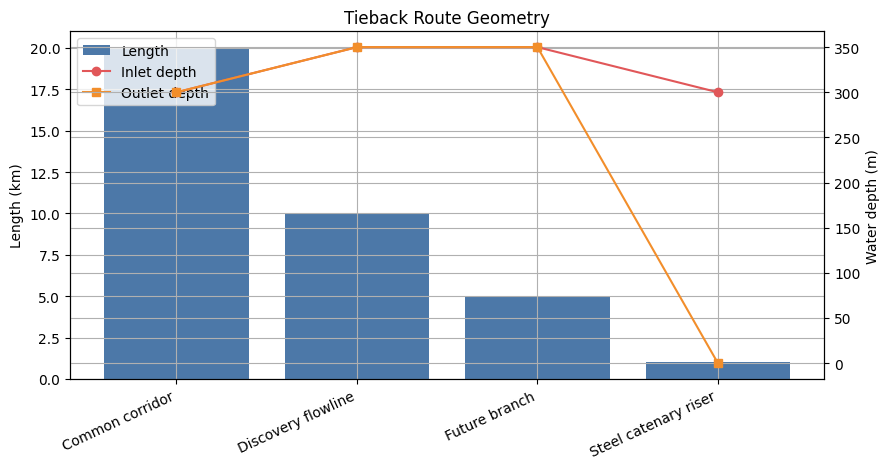

In [4]:
fig, ax1 = plt.subplots()
x = np.arange(len(route_df))
ax1.bar(x, route_df["length_km"], color="#4C78A8", label="Length")
ax1.set_ylabel("Length (km)")
ax1.set_xticks(x)
ax1.set_xticklabels(route_df["segment"], rotation=25, ha="right")
ax2 = ax1.twinx()
ax2.plot(x, route_df["inlet_depth_m"], color="#E15759", marker="o", label="Inlet depth")
ax2.plot(x, route_df["outlet_depth_m"], color="#F28E2B", marker="s", label="Outlet depth")
ax2.set_ylabel("Water depth (m)")
ax1.set_title("Tieback Route Geometry")
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="upper left")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "field_development_route_geometry.png", dpi=150, bbox_inches="tight")
plt.show()

**Figure discussion.** The route-network object separates hydraulic screening length from installed length. Shared corridors and branches increase installed CAPEX while preserving the main hydraulic path used for arrival pressure and temperature screening.

## 2. Multi-Well Gathering Network

`NetworkSolver` links simplified well performance to flowline pressure drop and facility capacity constraints. The example below allocates rates under a common manifold pressure and a maximum total gas rate.

In [5]:
well_a = create_gas_well("Well-A", 30.0, 3.0)
well_b = create_gas_well("Well-B", 25.0, 2.6)
well_c = create_gas_well("Well-C", 18.0, 2.1)

network = NetworkSolver("Satellite gathering")
network.addWell(well_a, 5.0, 0.16).addWell(well_b, 8.0, 0.18).addWell(well_c, 6.0, 0.14)
network.setManifoldPressure(55.0, "bara").setMaxTotalRate(1.8, "MSm3/day").setReferenceFluid(create_gas_fluid())
result = network.solve()

network_rows = []
for well_name in ["Well-A", "Well-B", "Well-C"]:
    network_rows.append({
        "well": well_name,
        "rate_MSm3d": result.getWellRate(well_name, "MSm3/day"),
        "wellhead_pressure_bara": result.getWellheadPressure(well_name),
        "flowline_dp_bar": result.getFlowlinePressureDrop(well_name),
        "enabled": bool(result.isWellEnabled(well_name)),
    })
network_df = pd.DataFrame(network_rows)
display(network_df.round(3))
print(result.getSummaryTable())

,well,rate_MSm3d,wellhead_pressure_bara,flowline_dp_bar,enabled
0,Well-A,0.733,56.654,1.654,True
1,Well-B,0.616,57.564,2.564,True
2,Well-C,0.451,56.949,1.949,True


# Network: Satellite gathering

**Manifold Pressure:** 55.0 bara
**Total Rate:** 1.80 MSm3/day
**Converged:** Yes (11 iterations)

| Well | Status | Rate (MSm3/d) | WHP (bara) | ΔP Flowline (bar) |
|------|--------|---------------|------------|-------------------|
| Well-C | ON | 0.45 | 56.9 | 1.9 |
| Well-B | ON | 0.62 | 57.6 | 2.6 |
| Well-A | ON | 0.73 | 56.7 | 1.7 |



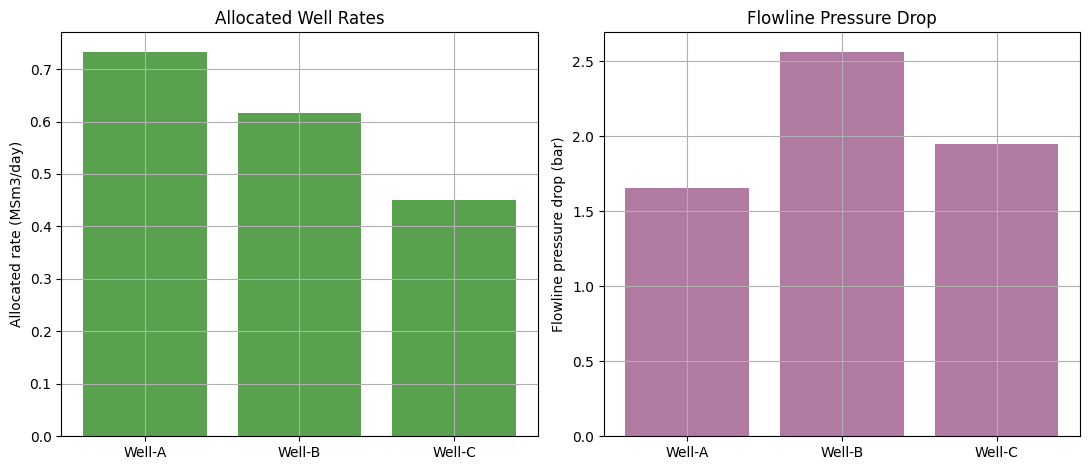

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
axes[0].bar(network_df["well"], network_df["rate_MSm3d"], color="#59A14F")
axes[0].set_ylabel("Allocated rate (MSm3/day)")
axes[0].set_title("Allocated Well Rates")
axes[1].bar(network_df["well"], network_df["flowline_dp_bar"], color="#B07AA1")
axes[1].set_ylabel("Flowline pressure drop (bar)")
axes[1].set_title("Flowline Pressure Drop")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "field_development_network_allocation.png", dpi=150, bbox_inches="tight")
plt.show()

**Figure discussion.** The facility rate cap scales the well potentials to a common total-rate limit. Longer or smaller-diameter flowlines produce higher pressure drop, which is exactly the screening signal needed before moving to a higher-fidelity pipe model.

## 3. Generate a Process Model From the Concept

`ConceptToProcessLinker` generates a process system from the concept basis. Run the process before reading utility summaries, because equipment power and duty are populated during `process.run()`.

In [7]:
linker = ConceptToProcessLinker()
process = linker.generateProcessSystem(concept, ConceptToProcessLinker.FidelityLevel.CONCEPT)
process.run()

unit_names = [str(process.getUnitOperations().get(i).getName()) for i in range(process.size())]
utility_df = pd.DataFrame([{
    "power_MW": linker.getTotalPowerMW(process),
    "heating_MW": linker.getTotalHeatingMW(process),
    "cooling_MW": linker.getTotalCoolingMW(process),
    "unit_count": process.size(),
}])
display(utility_df.round(3))
print("Generated units:")
for name in unit_names:
    print(f" - {name}")
print()
print(linker.getUtilitySummary(process))

,power_MW,heating_MW,cooling_MW,unit_count
0,72.298,0.0,132.847,6


Generated units:
 - Inlet
 - Slug-Catcher
 - Inlet-Cooler
 - Dehydration
 - Export-Compressor
 - Export-Cooler

=== UTILITY SUMMARY ===

Power consumption:  72.30 MW
Heating duty:       0.00 MW
Cooling duty:       132.85 MW
Est. CO2 emissions: 312.3 tonnes/day



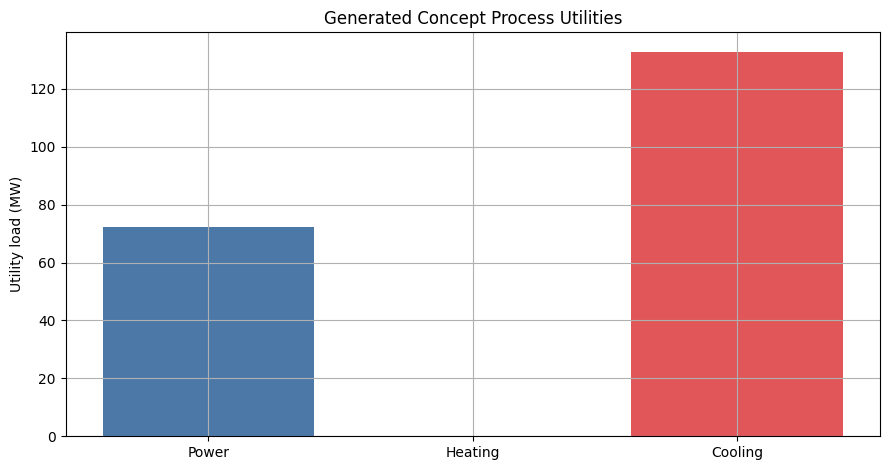

In [8]:
utility_plot = utility_df[["power_MW", "heating_MW", "cooling_MW"]].iloc[0]
fig, ax = plt.subplots()
ax.bar(["Power", "Heating", "Cooling"], utility_plot.values, color=["#4C78A8", "#F28E2B", "#E15759"])
ax.set_ylabel("Utility load (MW)")
ax.set_title("Generated Concept Process Utilities")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "field_development_process_utilities.png", dpi=150, bbox_inches="tight")
plt.show()

**Figure discussion.** The generated process model gives immediate utility estimates from the concept basis. For this gas satellite, export compression dominates the utility picture, which links the field-development decision back to process equipment sizing and emissions.

## 4. Export VFP and Schedule Data

`ReservoirCouplingExporter` creates VFPPROD/VFPINJ tables and schedule keyword snippets for reservoir-simulator coupling. Use at least two points in each range.

In [9]:
exporter = ReservoirCouplingExporter()
exporter.setPressureRange(20.0, 60.0, 3)
exporter.setRateRange(500.0, 1500.0, 4)
exporter.setWctRange(0.0, 0.5, 2)
exporter.setGorRange(100.0, 300.0, 2)
exporter.setDatumDepth(2000.0)

prod_table = exporter.generateVfpProd("PROD-1", create_gas_fluid(), 7)
inj_table = exporter.generateVfpInj("INJ-1", create_gas_fluid(), 8)
calendar = GregorianCalendar(2028, Calendar.JANUARY, 1)
exporter.addGroupConstraint(calendar.getTime(), "HOST", 5000.0, 2.0e6, 2000.0)
exporter.addWellControl(calendar.getTime(), "PROD-1", "GRAT", 1.5e6)
exporter.addVfpReference(calendar.getTime(), "PROD-1", 7)

flow_rates = [float(value) for value in prod_table.getFlowRates()]
thp_values = [float(value) for value in prod_table.getThpValues()]
bhp = prod_table.getBhpValues()
vfp_rows = []
for i, rate in enumerate(flow_rates):
    for j, thp in enumerate(thp_values):
        vfp_rows.append({
            "rate_Sm3d": rate,
            "thp_bara": thp,
            "bhp_bara": float(bhp[i][j][0][0][0]),
        })
vfp_df = pd.DataFrame(vfp_rows)
display(vfp_df.round(2))

keywords = exporter.getEclipseKeywords()
print("First keyword lines:")
print("\n".join(keywords.splitlines()[:28]))
print(f"Generated VFP tables: {exporter.getVfpTables().size()}")

,rate_Sm3d,thp_bara,bhp_bara
0,500.00,20.0,176.97
1,500.00,40.0,196.97
2,500.00,60.0,216.97
3,833.33,20.0,176.97
4,833.33,40.0,196.97
5,833.33,60.0,216.97
6,1166.67,20.0,176.99
7,1166.67,40.0,196.99
8,1166.67,60.0,216.99
9,1500.00,20.0,177.00


First keyword lines:
-- ==========================================================
-- NeqSim Process Model Export
-- Generated: 2026-05-05 19:48:46
-- ==========================================================

VFPPROD
-- VFP Production Table 7 for PROD-1
-- Generated by NeqSim 2026-05-05 19:48
  7  2000.0  'LIQ'  'WCT'  'GOR'  'THP'  '' 'METRIC'  'BHP' /
-- Flow rates (Sm3/d)
  500.0  833.3  1166.7  1500.0  /
-- THP (bara)
  20.0  40.0  60.0  /
-- Water cut
  0.000  0.500  /
-- GOR (Sm3/Sm3)
  100.0  300.0  /
-- ALQ
  0.0  /
-- BHP values (bara)
-- THP=20 WCT=0.00 GOR=100
  176.97  176.97  176.99  177.00  /
-- THP=20 WCT=0.00 GOR=300
  176.97  176.97  176.99  177.00  /
-- THP=20 WCT=0.50 GOR=100
  157.35  157.35  157.37  157.38  /
-- THP=20 WCT=0.50 GOR=300
  157.35  157.35  157.37  157.38  /
Generated VFP tables: 2


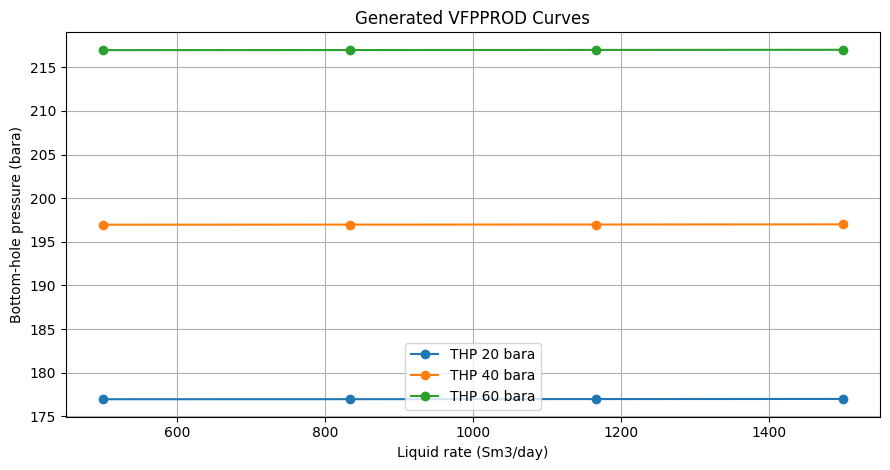

In [10]:
fig, ax = plt.subplots()
for thp, group in vfp_df.groupby("thp_bara"):
    ax.plot(group["rate_Sm3d"], group["bhp_bara"], marker="o", label=f"THP {thp:.0f} bara")
ax.set_xlabel("Liquid rate (Sm3/day)")
ax.set_ylabel("Bottom-hole pressure (bara)")
ax.set_title("Generated VFPPROD Curves")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "field_development_vfp_curves.png", dpi=150, bbox_inches="tight")
plt.show()

**Figure discussion.** The VFP curves increase bottom-hole pressure with both rate and tubing-head pressure. The exported keyword snippet lets a reservoir model use the same screening assumptions for well deliverability and facility constraints.

## Takeaways

The coupling utilities connect field-development screening to the next engineering layers: route networks preserve topology, network solving exposes well and flowline constraints, concept linking produces process utilities, and reservoir export generates VFP and schedule artifacts for simulator coupling.